# Aircraft Performance Comparison

HyPlan includes 14 pre-configured research aircraft models spanning high-altitude
jets (ER-2, WB-57) to low-altitude turboprops (Twin Otter, King Air). This notebook
explores their performance characteristics to help select the right platform.

We cover:

1. Fleet overview — ceiling, speed, endurance, payload
2. True airspeed vs. altitude (speed profiles)
3. Climb performance and profiles
4. Descent speed modeling
5. Range and endurance trade-offs
6. Selecting aircraft for a mission
7. Defining a custom aircraft

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hyplan.aircraft import (
    Aircraft,
    NASA_ER2, NASA_GIII, NASA_GIV, NASA_C20A, NASA_P3,
    NASA_WB57, NASA_B777,
    DynamicAviation_B200, DynamicAviation_DH8, DynamicAviation_A90,
    C130, BAe146, Learjet, TwinOtter,
)
from hyplan.units import ureg

## 1. Fleet Overview

Compare key specifications across all available aircraft.

In [3]:
fleet = [
    NASA_ER2(), NASA_WB57(), NASA_GIII(), NASA_GIV(), NASA_C20A(),
    NASA_P3(), NASA_B777(), DynamicAviation_B200(), DynamicAviation_DH8(),
    DynamicAviation_A90(), C130(), BAe146(), Learjet(), TwinOtter(),
]

rows = []
for ac in fleet:
    rows.append({
        "Aircraft": ac.aircraft_type,
        "Tail": ac.tail_number,
        "Operator": ac.operator,
        "Ceiling (ft)": f"{ac.service_ceiling.magnitude:,.0f}",
        "Cruise (kt)": f"{ac.cruise_speed.magnitude:.0f}",
        "Endurance (hr)": f"{ac.endurance.magnitude:.1f}",
        "Range (nmi)": f"{ac.range.magnitude:,.0f}",
        "Payload (lb)": f"{ac.useful_payload.magnitude:,.0f}",
    })

fleet_df = pd.DataFrame(rows)
fleet_df

,Aircraft,Tail,Operator,Ceiling (ft),Cruise (kt),Endurance (hr),Range (nmi),Payload (lb)
0,ER-2,NASA 806,NASA AFRC,"70,000",410,8.0,"5,000","2,900"
1,WB-57,NASA 927,NASA JSC,"60,000",410,6.5,"2,500","8,800"
2,Gulfstream III,NASA 520,NASA LaRC,"45,000",459,7.5,"3,767","2,610"
3,Gulfstream IV,NASA 817,NASA AFRC,"45,000",459,7.5,"5,130","5,610"
4,C-20A,NASA 502,NASA AFRC,"45,000",460,6.0,"3,400","2,500"
5,P-3 Orion,NASA 426,NASA LaRC,"32,000",301,12.0,"3,800","18,000"
6,B777,Unknown,NASA LaRC,"43,000",487,18.0,"9,000","75,000"
7,King Air 200,Unknown,Dynamic Aviation,"35,000",250,6.0,"1,632","4,250"
8,Dash 8,Unknown,Dynamic Aviation,"25,000",243,5.0,950,"15,000"
9,King Air 90,Unknown,Dynamic Aviation,"30,000",230,6.0,"1,500","2,950"


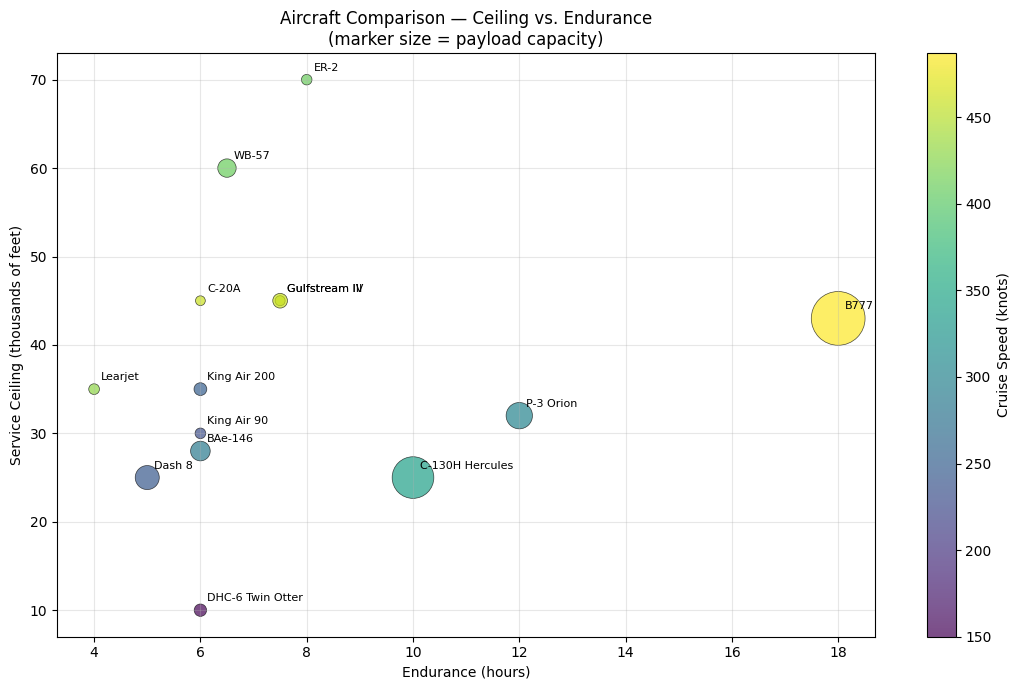

In [4]:
# Visual comparison: ceiling vs endurance, sized by payload
fig, ax = plt.subplots(figsize=(11, 7))

ceilings = [ac.service_ceiling.magnitude / 1000 for ac in fleet]
endurances = [ac.endurance.magnitude for ac in fleet]
payloads = [ac.useful_payload.magnitude for ac in fleet]
labels = [ac.aircraft_type for ac in fleet]

scatter = ax.scatter(
    endurances, ceilings,
    s=[p / 50 for p in payloads],  # scale marker size
    c=[ac.cruise_speed.magnitude for ac in fleet],
    cmap="viridis", alpha=0.7, edgecolors="black", linewidth=0.5,
)

for i, label in enumerate(labels):
    ax.annotate(label, (endurances[i], ceilings[i]),
                fontsize=8, ha="left", va="bottom", xytext=(5, 5),
                textcoords="offset points")

plt.colorbar(scatter, ax=ax, label="Cruise Speed (knots)")
ax.set_xlabel("Endurance (hours)")
ax.set_ylabel("Service Ceiling (thousands of feet)")
ax.set_title("Aircraft Comparison — Ceiling vs. Endurance\n(marker size = payload capacity)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Speed Profiles

Each aircraft has an altitude-dependent true airspeed (TAS) model. These are
piecewise-linear profiles derived from operational data. TAS generally
increases with altitude for jet and turboprop aircraft.

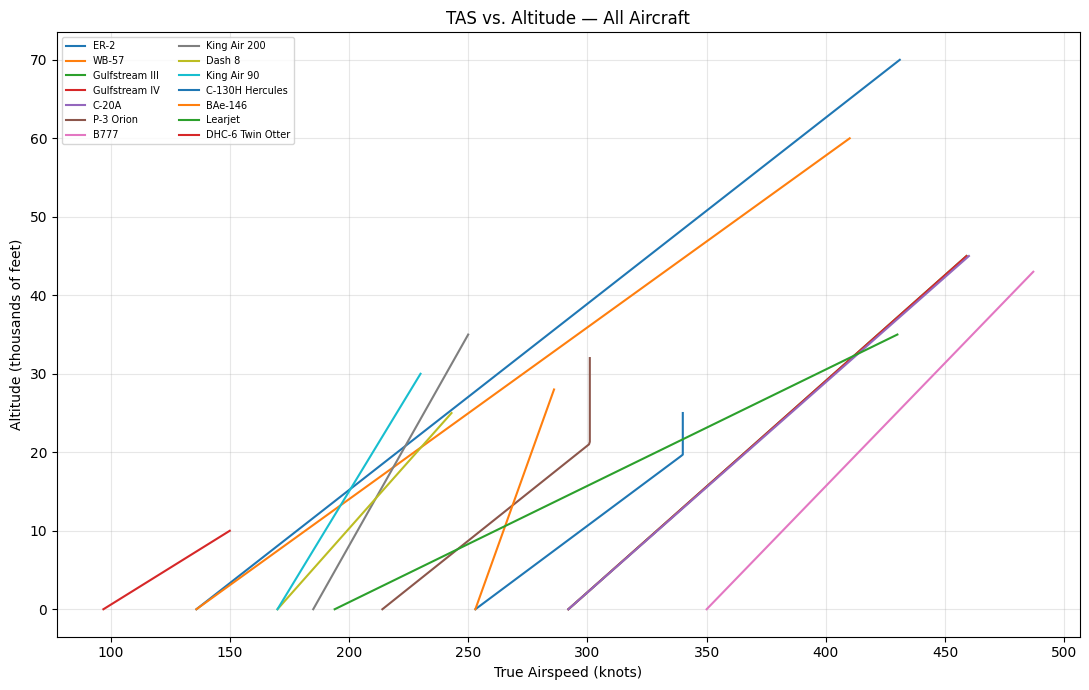

In [5]:
fig, ax = plt.subplots(figsize=(11, 7))

for ac in fleet:
    alts = np.linspace(0, ac.service_ceiling.magnitude, 100) * ureg.feet
    speeds = [ac.cruise_speed_at(a).to(ureg.knot).magnitude for a in alts]
    ax.plot(speeds, [a.magnitude / 1000 for a in alts], label=ac.aircraft_type)

ax.set_xlabel("True Airspeed (knots)")
ax.set_ylabel("Altitude (thousands of feet)")
ax.set_title("TAS vs. Altitude — All Aircraft")
ax.legend(fontsize=7, loc="upper left", ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Speed table at key altitudes
rows = []
for ac in fleet:
    ceil = ac.service_ceiling.magnitude
    rows.append({
        "Aircraft": ac.aircraft_type,
        "Sea Level (kt)": f"{ac.cruise_speed_at(0 * ureg.feet).to(ureg.knot).magnitude:.0f}",
        "Mid-Alt (kt)": f"{ac.cruise_speed_at(ceil / 2 * ureg.feet).to(ureg.knot).magnitude:.0f}",
        "Ceiling (kt)": f"{ac.cruise_speed_at(ceil * ureg.feet).to(ureg.knot).magnitude:.0f}",
        "Descent @ Mid (kt)": f"{ac.descent_speed_at(ceil / 2 * ureg.feet).to(ureg.knot).magnitude:.0f}",
    })

speed_df = pd.DataFrame(rows)
speed_df

,Aircraft,Sea Level (kt),Mid-Alt (kt),Ceiling (kt),Descent @ Mid (kt)
0,ER-2,136,284,431,284
1,WB-57,136,273,410,273
2,Gulfstream III,292,376,459,326
3,Gulfstream IV,292,376,459,326
4,C-20A,292,376,460,327
5,P-3 Orion,214,280,301,251
6,B777,350,418,487,388
7,King Air 200,185,218,250,208
8,Dash 8,170,206,243,192
9,King Air 90,170,200,230,190


## 3. Climb Performance

Rate of climb (ROC) decreases with altitude. HyPlan uses an analytical
model that produces realistic curved climb profiles.

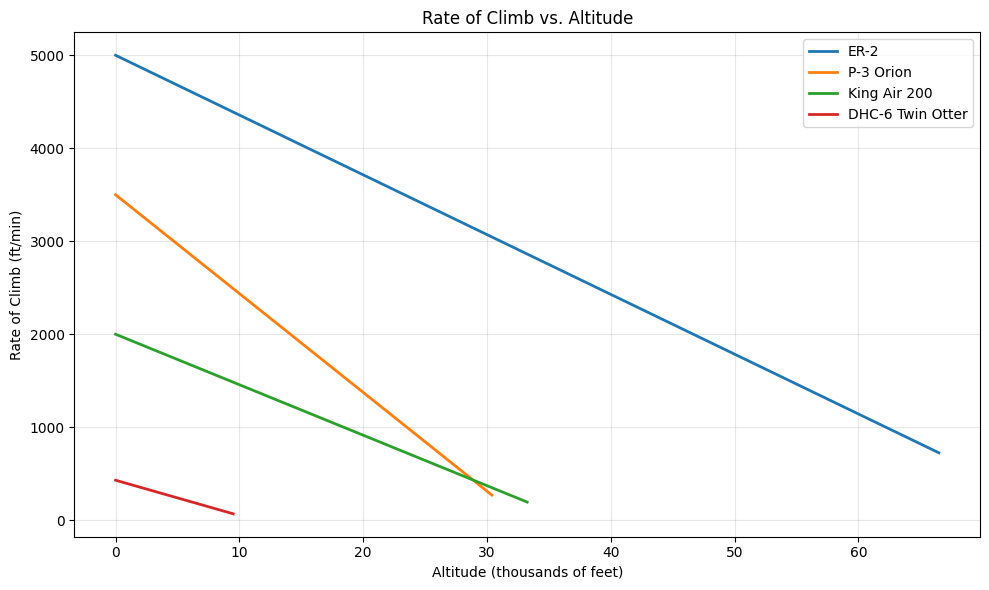

In [7]:
# Rate of climb vs altitude for selected aircraft
selected = [NASA_ER2(), NASA_P3(), DynamicAviation_B200(), TwinOtter()]

fig, ax = plt.subplots(figsize=(10, 6))

for ac in selected:
    alts = np.linspace(0, ac.service_ceiling.magnitude * 0.95, 100) * ureg.feet
    rocs = [ac.rate_of_climb(a).to(ureg.feet / ureg.minute).magnitude for a in alts]
    ax.plot([a.magnitude / 1000 for a in alts], rocs, label=ac.aircraft_type, linewidth=2)

ax.set_xlabel("Altitude (thousands of feet)")
ax.set_ylabel("Rate of Climb (ft/min)")
ax.set_title("Rate of Climb vs. Altitude")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

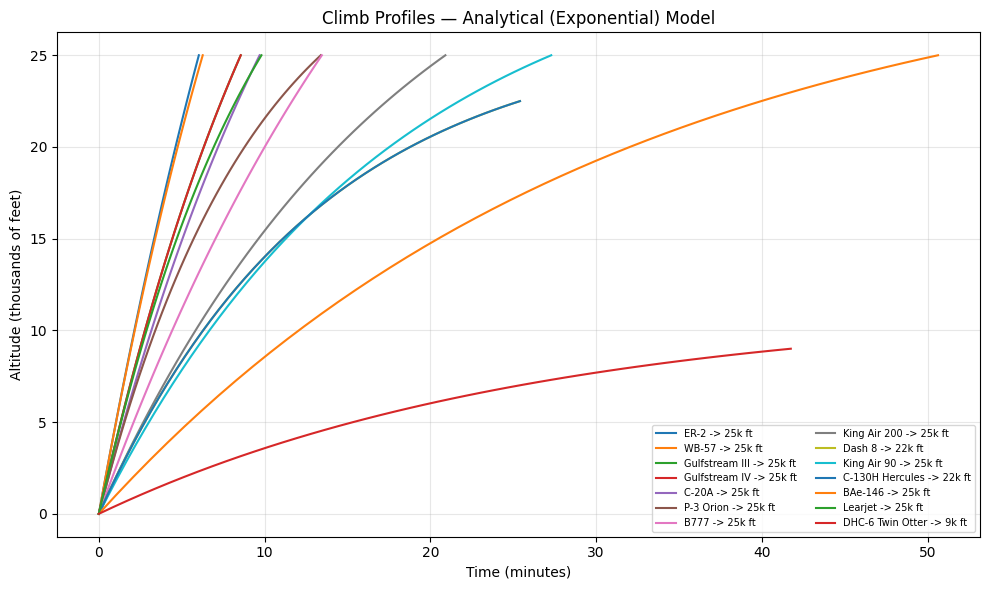

In [8]:
# Climb profiles — altitude vs time
fig, ax = plt.subplots(figsize=(10, 6))

for ac in fleet:
    target_alt = min(25000, ac.service_ceiling.magnitude * 0.9)
    times, alts = ac.climb_altitude_profile(0 * ureg.feet, target_alt * ureg.feet)
    ax.plot(times, alts / 1000, label=f"{ac.aircraft_type} -> {target_alt / 1000:.0f}k ft")

ax.set_xlabel("Time (minutes)")
ax.set_ylabel("Altitude (thousands of feet)")
ax.set_title("Climb Profiles — Analytical (Exponential) Model")
ax.legend(fontsize=7, loc="lower right", ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Analytical vs. Linear Climb Model

The analytical model produces a realistic curve that starts steep
at low altitude and flattens as ROC decreases. Compare with a naive
linear (average ROC) estimate.

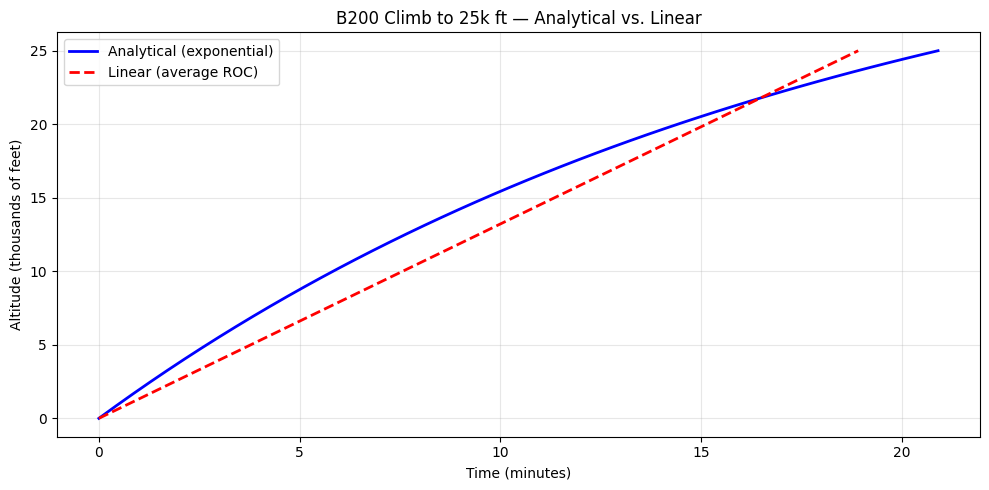

Analytical climb time: 20.9 min
Linear estimate:       18.9 min


In [9]:
b200 = DynamicAviation_B200()
target = 25000 * ureg.feet

# Analytical profile
times_analytical, alts_analytical = b200.climb_altitude_profile(0 * ureg.feet, target)

# Linear profile (old model: constant average ROC)
roc_start = b200.rate_of_climb(0 * ureg.feet).to(ureg.feet / ureg.minute).magnitude
roc_end = b200.rate_of_climb(target).to(ureg.feet / ureg.minute).magnitude
avg_roc = (roc_start + roc_end) / 2
linear_total_time = target.magnitude / avg_roc
times_linear = np.linspace(0, linear_total_time, 50)
alts_linear = np.linspace(0, target.magnitude, 50)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(times_analytical, alts_analytical / 1000, "b-", linewidth=2, label="Analytical (exponential)")
ax.plot(times_linear, alts_linear / 1000, "r--", linewidth=2, label="Linear (average ROC)")
ax.set_xlabel("Time (minutes)")
ax.set_ylabel("Altitude (thousands of feet)")
ax.set_title(f"B200 Climb to {target.magnitude / 1000:.0f}k ft — Analytical vs. Linear")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Analytical climb time: {times_analytical[-1]:.1f} min")
print(f"Linear estimate:       {linear_total_time:.1f} min")

## 5. Range and Endurance

Range determines how far from base an aircraft can operate; endurance
determines how long it can stay on station. The effective data-collection
time is endurance minus climb, transit, and descent time.

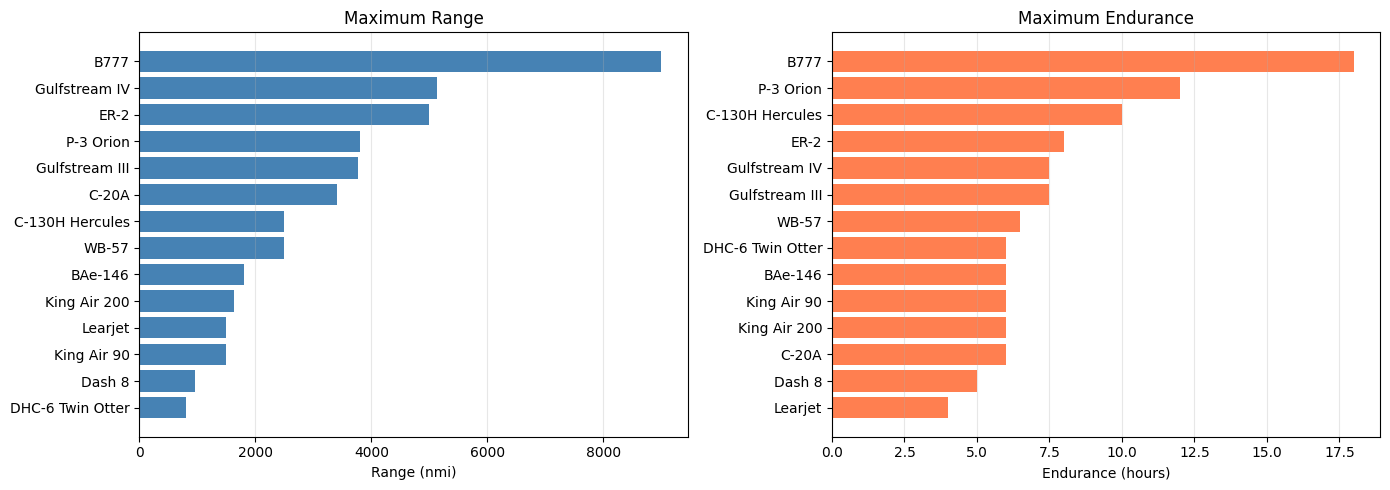

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = [ac.aircraft_type for ac in fleet]
ranges = [ac.range.magnitude for ac in fleet]
endurances = [ac.endurance.magnitude for ac in fleet]

# Sort by range
sort_idx = np.argsort(ranges)

axes[0].barh([names[i] for i in sort_idx], [ranges[i] for i in sort_idx], color="steelblue")
axes[0].set_xlabel("Range (nmi)")
axes[0].set_title("Maximum Range")
axes[0].grid(True, axis="x", alpha=0.3)

# Sort by endurance
sort_idx = np.argsort(endurances)

axes[1].barh([names[i] for i in sort_idx], [endurances[i] for i in sort_idx], color="coral")
axes[1].set_xlabel("Endurance (hours)")
axes[1].set_title("Maximum Endurance")
axes[1].grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Selecting an Aircraft for a Mission

Given mission requirements (target altitude, minimum endurance, minimum
payload), filter the fleet to find suitable platforms.

In [11]:
# Mission requirements
required_altitude = 25000  # feet
required_endurance = 5.0   # hours
required_payload = 2000    # pounds

print(f"Mission Requirements:")
print(f"  Min altitude:  {required_altitude:,} ft")
print(f"  Min endurance: {required_endurance} hr")
print(f"  Min payload:   {required_payload:,} lb")
print()

suitable = []
for ac in fleet:
    if (ac.service_ceiling.magnitude >= required_altitude
        and ac.endurance.magnitude >= required_endurance
        and ac.useful_payload.magnitude >= required_payload):
        suitable.append(ac)
        print(f"  OK  {ac.aircraft_type:25s}  ceil={ac.service_ceiling.magnitude:,.0f} ft  "
              f"endur={ac.endurance.magnitude:.1f} hr  payload={ac.useful_payload.magnitude:,.0f} lb")

if not suitable:
    print("  No aircraft meets all requirements.")
else:
    print(f"\n{len(suitable)} aircraft meet the requirements.")

Mission Requirements:
  Min altitude:  25,000 ft
  Min endurance: 5.0 hr
  Min payload:   2,000 lb

  OK  ER-2                       ceil=70,000 ft  endur=8.0 hr  payload=2,900 lb
  OK  WB-57                      ceil=60,000 ft  endur=6.5 hr  payload=8,800 lb
  OK  Gulfstream III             ceil=45,000 ft  endur=7.5 hr  payload=2,610 lb
  OK  Gulfstream IV              ceil=45,000 ft  endur=7.5 hr  payload=5,610 lb
  OK  C-20A                      ceil=45,000 ft  endur=6.0 hr  payload=2,500 lb
  OK  P-3 Orion                  ceil=32,000 ft  endur=12.0 hr  payload=18,000 lb
  OK  B777                       ceil=43,000 ft  endur=18.0 hr  payload=75,000 lb
  OK  King Air 200               ceil=35,000 ft  endur=6.0 hr  payload=4,250 lb
  OK  Dash 8                     ceil=25,000 ft  endur=5.0 hr  payload=15,000 lb
  OK  King Air 90                ceil=30,000 ft  endur=6.0 hr  payload=2,950 lb
  OK  C-130H Hercules            ceil=25,000 ft  endur=10.0 hr  payload=45,000 lb
  OK  BAe-146

## 7. Defining a Custom Aircraft

You can define your own aircraft by instantiating the `Aircraft` class
directly. All performance parameters use Pint quantities for
unit safety.

In [12]:
custom = Aircraft(
    aircraft_type="Cessna Grand Caravan",
    tail_number="N12345",
    service_ceiling=25000 * ureg.feet,
    approach_speed=85 * ureg.knot,
    best_rate_of_climb=1215 * ureg.feet / ureg.minute,
    cruise_speed=186 * ureg.knot,
    range=986 * ureg.nautical_mile,
    endurance=5.0 * ureg.hour,
    operator="Custom Operator",
    max_bank_angle=25.0,
    useful_payload=3530 * ureg.pound,
    vx=90 * ureg.knot,
    vy=105 * ureg.knot,
    roc_at_service_ceiling=100 * ureg.feet / ureg.minute,
    descent_rate=1000 * ureg.feet / ureg.minute,
    descent_speed_reduction=10 * ureg.knot,
    speed_profile=[
        (0 * ureg.feet, 140 * ureg.knot),
        (25000 * ureg.feet, 186 * ureg.knot),
    ],
)

print(f"{custom.aircraft_type}:")
print(f"  Ceiling:   {custom.service_ceiling}")
print(f"  Cruise:    {custom.cruise_speed}")
print(f"  Endurance: {custom.endurance}")
print(f"  Payload:   {custom.useful_payload}")

# Verify speed profile works
for alt_ft in [0, 10000, 25000]:
    spd = custom.cruise_speed_at(alt_ft * ureg.feet).to(ureg.knot)
    print(f"  TAS at {alt_ft:,} ft: {spd:.0f}")

Cessna Grand Caravan:
  Ceiling:   25000 foot
  Cruise:    186 knot
  Endurance: 5.0 hour
  Payload:   3530 pound
  TAS at 0 ft: 140 knot
  TAS at 10,000 ft: 158 knot
  TAS at 25,000 ft: 186 knot


## Summary

| Feature | Class/Method | Purpose |
|---------|-------------|----------|
| Pre-configured aircraft | `NASA_ER2()`, `DynamicAviation_B200()`, etc. | 14 research aircraft |
| Custom aircraft | `Aircraft(...)` | User-defined platforms |
| Speed at altitude | `cruise_speed_at(altitude)` | Altitude-dependent TAS |
| Descent speed | `descent_speed_at(altitude)` | TAS during descent |
| Rate of climb | `rate_of_climb(altitude)` | ROC at any altitude |
| Climb profile | `climb_altitude_profile(start, end)` | Realistic altitude vs. time |
| Flight phases | `time_to_takeoff()`, `time_to_cruise()`, `time_to_return()` | Phase-by-phase timing |